# Segmentation Viability Check

**Goal:** Determine which Country × Role Cluster × Location × Quarter segments have enough volume to forecast reliably.

**Steps:**
1. Join `role_cluster` onto the 42k clean records
2. Build the full segment key (region + role_cluster + location + quarter)
3. Tier classification: Tier 1 (≥30/qtr → SARIMAX), Tier 2 (10-30/qtr → ExpSmooth), Tier 3 (<10/qtr → historical avg)
4. Coverage summary table for leadership
5. Sparse segment handling / rollup strategy
6. Quarter completeness check for Tier 1/2 segments

**Output:** Definitive list of forecastable segments with tier assignments.

In [2]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Load & Join
#
# Load clean_42k_v1.pkl and title_to_cluster.pkl.
# Join on raw title to bring role_cluster onto every record.
# Verify zero nulls after the join.
# ═══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')

# Load datasets
df = pd.read_pickle(os.path.join(data_dir, 'clean_42k_v1.pkl'))
mapping = pd.read_pickle(os.path.join(data_dir, 'title_to_cluster.pkl'))

print(f"Clean records: {df.shape}")
print(f"Title mapping: {mapping.shape}")
print(f"Unique clusters in mapping: {mapping['role_cluster'].nunique()}")

# Join: map raw title → role_cluster
title_to_role = dict(zip(mapping['raw_title'], mapping['role_cluster']))
df['role_cluster'] = df['title'].map(title_to_role)

# Verify zero nulls
nulls = df['role_cluster'].isna().sum()
if nulls > 0:
    print(f"\n⚠️  BUG: {nulls} records have no role_cluster!")
    unmapped = df[df['role_cluster'].isna()]['title'].value_counts().head(10)
    print(f"Unmapped titles:")
    print(unmapped)
else:
    print(f"\n✅ All {len(df):,} records mapped to a role_cluster. Zero nulls.")

print(f"\n── Column inventory: ──")
print(df.columns.tolist())
print(f"\n── Sample: ──")
print(df[['title', 'role_cluster', 'region', 'location', 'issue_date']].head(10))

Clean records: (42016, 8)
Title mapping: (11416, 3)
Unique clusters in mapping: 50

✅ All 42,016 records mapped to a role_cluster. Zero nulls.

── Column inventory: ──
['issue_date', 'region', 'location', 'title', 'company_name', 'openings', 'fills', 'skills_clean', 'role_cluster']

── Sample: ──
                                         title              role_cluster  \
48                               Recruiter III                 Recruiter   
63   Technical Customer Support Representative          Customer Service   
70                          engineer associate     Engineering - General   
86             Assistant Merchandise Manager I  Administrative Assistant   
88      Usability Researcher (Non-Engineering)      Operations - General   
97                 Business Systems Analyst IV  Business Systems Analyst   
105                     Solution Architect III                 Architect   
107                              Engineer - 24     Engineering - General   
128   Cloud Projec

In [3]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Build Segment Key & Quarterly Counts
#
# Forecasting grain: Region × Role Cluster × Location × Quarter
# Create quarter from issue_date, then group and count.
# ═══════════════════════════════════════════════════════════════

# Create quarter period from issue_date
df['issue_date'] = pd.to_datetime(df['issue_date'])
df['quarter'] = df['issue_date'].dt.to_period('Q')

# Build segment key
df['segment_key'] = (
    df['region'] + ' | ' +
    df['role_cluster'] + ' | ' +
    df['location'].fillna('Unknown')
)

# Quarterly counts per segment
seg_quarterly = (
    df.groupby(['segment_key', 'quarter'])
    .size()
    .reset_index(name='record_count')
)

# Also build the component columns for easier analysis
seg_quarterly[['region', 'role_cluster', 'location']] = (
    seg_quarterly['segment_key'].str.split(' \| ', expand=True)
)

print(f"Total unique segments: {seg_quarterly['segment_key'].nunique():,}")
print(f"Quarter range: {seg_quarterly['quarter'].min()} → {seg_quarterly['quarter'].max()}")
print(f"Total segment-quarter observations: {len(seg_quarterly):,}")

# How many quarters do we have?
all_quarters = sorted(seg_quarterly['quarter'].unique())
print(f"\nAll quarters ({len(all_quarters)}): {[str(q) for q in all_quarters]}")

# Quick distribution
print(f"\n── Records per quarter (total): ──")
qtr_totals = df.groupby('quarter').size()
for q, n in qtr_totals.items():
    print(f"  {q}: {n:,}")

Total unique segments: 1,799
Quarter range: 2017Q1 → 2026Q2
Total segment-quarter observations: 10,833

All quarters (38): ['2017Q1', '2017Q2', '2017Q3', '2017Q4', '2018Q1', '2018Q2', '2018Q3', '2018Q4', '2019Q1', '2019Q2', '2019Q3', '2019Q4', '2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4', '2022Q1', '2022Q2', '2022Q3', '2022Q4', '2023Q1', '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4', '2026Q1', '2026Q2']

── Records per quarter (total): ──
  2017Q1: 8
  2017Q2: 64
  2017Q3: 615
  2017Q4: 1,030
  2018Q1: 88
  2018Q2: 106
  2018Q3: 148
  2018Q4: 89
  2019Q1: 130
  2019Q2: 137
  2019Q3: 98
  2019Q4: 55
  2020Q1: 85
  2020Q2: 47
  2020Q3: 62
  2020Q4: 54
  2021Q1: 20
  2021Q2: 34
  2021Q3: 34
  2021Q4: 19
  2022Q1: 286
  2022Q2: 381
  2022Q3: 3,129
  2022Q4: 2,399
  2023Q1: 2,893
  2023Q2: 2,624
  2023Q3: 2,515
  2023Q4: 2,180
  2024Q1: 2,461
  2024Q2: 2,265
  2024Q3: 2,598
  2024Q4: 2,291
  202

In [4]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — Tier Classification
#
# For each segment (Region × Role Cluster × Location), compute
# average records per quarter across the training window.
#
# Tier 1: ≥30/quarter → SARIMAX-eligible
# Tier 2: 10-30/quarter → Exponential Smoothing
# Tier 3: <10/quarter → Historical average only
# ═══════════════════════════════════════════════════════════════

# Define training window (2022 Q1 – 2025 Q4)
train_start = pd.Period('2022Q1', freq='Q')
train_end = pd.Period('2025Q4', freq='Q')
train_quarters = [q for q in all_quarters if train_start <= q <= train_end]
n_train_quarters = len(train_quarters)

print(f"Training window: {train_start} → {train_end} ({n_train_quarters} quarters)")

# Filter to training window
seg_train = seg_quarterly[seg_quarterly['quarter'].isin(train_quarters)]

# Average records per quarter for each segment
seg_stats = seg_train.groupby('segment_key').agg(
    total_records=('record_count', 'sum'),
    quarters_present=('quarter', 'nunique'),
    avg_per_quarter=('record_count', 'mean'),
    min_quarter=('record_count', 'min'),
    max_quarter=('record_count', 'max'),
).reset_index()

# Split segment_key back into components
seg_stats[['region', 'role_cluster', 'location']] = (
    seg_stats['segment_key'].str.split(' \| ', expand=True)
)

# Tier assignment
def assign_tier(avg):
    if avg >= 30:
        return 'Tier 1'
    elif avg >= 10:
        return 'Tier 2'
    else:
        return 'Tier 3'

seg_stats['tier'] = seg_stats['avg_per_quarter'].apply(assign_tier)

# Summary
tier_summary = seg_stats.groupby('tier').agg(
    n_segments=('segment_key', 'count'),
    total_records=('total_records', 'sum'),
    avg_records_per_qtr=('avg_per_quarter', 'mean'),
).sort_index()

print(f"\n{'═'*70}")
print("TIER CLASSIFICATION SUMMARY")
print(f"{'═'*70}")
print(f"\n{'Tier':<10} {'Segments':<12} {'Total Records':<16} {'Avg/Qtr (mean)':<16} {'Model'}")
print("─"*70)

model_map = {'Tier 1': 'SARIMAX', 'Tier 2': 'Exp. Smoothing', 'Tier 3': 'Historical Avg'}
total_all = seg_stats['total_records'].sum()

for tier, row in tier_summary.iterrows():
    pct = row['total_records'] / total_all * 100
    print(f"{tier:<10} {row['n_segments']:<12,.0f} {row['total_records']:<16,.0f} "
          f"{row['avg_records_per_qtr']:<16.1f} {model_map[tier]}")
    print(f"{'':10} {'':12} ({pct:.1f}% of records)")

print(f"\nTotal segments: {len(seg_stats):,}")
print(f"Forecastable (Tier 1+2): {(seg_stats['tier'].isin(['Tier 1', 'Tier 2'])).sum():,} segments")

Training window: 2022Q1 → 2025Q4 (16 quarters)

══════════════════════════════════════════════════════════════════════
TIER CLASSIFICATION SUMMARY
══════════════════════════════════════════════════════════════════════

Tier       Segments     Total Records    Avg/Qtr (mean)   Model
──────────────────────────────────────────────────────────────────────
Tier 1     7            3,927            39.1             SARIMAX
                        (11.0% of records)
Tier 2     49           10,109           15.8             Exp. Smoothing
                        (28.3% of records)
Tier 3     1,631        21,682           2.0              Historical Avg
                        (60.7% of records)

Total segments: 1,687
Forecastable (Tier 1+2): 56 segments


══════════════════════════════════════════════════════════════════════
COVERAGE SUMMARY BY REGION — Leadership Table
══════════════════════════════════════════════════════════════════════

Region   Tier     Segments   Records      % of Region  Model
──────────────────────────────────────────────────────────────────────
US       Tier 1   4          2,453        8.8          SARIMAX
US       Tier 2   39         8,433        30.2         Exp. Smoothing
US       Tier 3   1281       17,064       61.1         Historical Avg
         TOTAL    1324       27,950                   
         → Forecastable (T1+T2):        38.9% of records

IN       Tier 1   3          1,474        20.1         SARIMAX
IN       Tier 2   9          1,548        21.2         Exp. Smoothing
IN       Tier 3   310        4,297        58.7         Historical Avg
         TOTAL    322        7,319                    
         → Forecastable (T1+T2):        41.3% of records

LATAM    Tier 1   0          0            0.0  

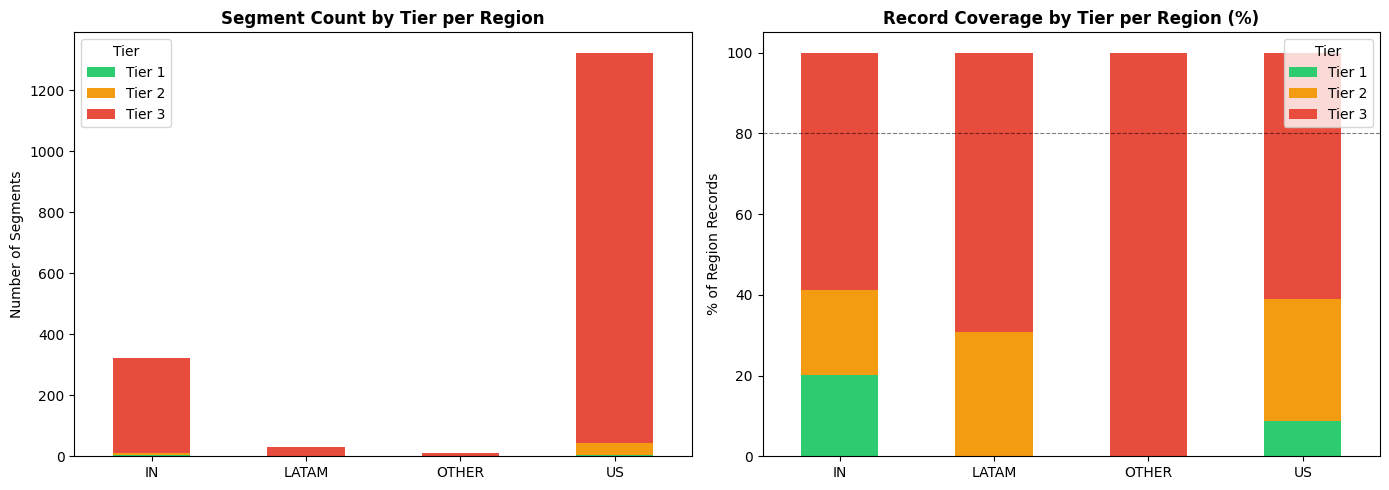


── Top 20 Tier 1 Segments (highest volume): ──
Rank  Region Role Cluster                        Location             Avg/Qtr    Total
─────────────────────────────────────────────────────────────────────────────────────
1     US     Program Manager                     WA                   52.0       728
2     US     Engineering - General               CA                   44.8       627
3     US     Program Manager                     CA                   39.9       559
4     US     Software Engineer                   WA                   38.5       539
5     IN     Developer                           Bangalore            34.9       523
6     IN     Software Engineer                   Pune                 32.4       486
7     IN     Java Developer (India)              Unknown              31.0       465


In [5]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — Coverage Summary Table (Leadership View)
#
# For each region (US, IN, LATAM): how many Tier 1/2/3 segments,
# what % of that region's records fall into each tier.
# This is the table you present to leadership.
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

print("═"*70)
print("COVERAGE SUMMARY BY REGION — Leadership Table")
print("═"*70)
print(f"\n{'Region':<8} {'Tier':<8} {'Segments':<10} {'Records':<12} {'% of Region':<12} {'Model'}")
print("─"*70)

for region in ['US', 'IN', 'LATAM']:
    region_data = seg_stats[seg_stats['region'] == region]
    region_total = region_data['total_records'].sum()
    
    for tier in ['Tier 1', 'Tier 2', 'Tier 3']:
        tier_data = region_data[region_data['tier'] == tier]
        n_seg = len(tier_data)
        rec = tier_data['total_records'].sum()
        pct = rec / region_total * 100 if region_total > 0 else 0
        print(f"{region:<8} {tier:<8} {n_seg:<10} {rec:<12,} {pct:<12.1f} {model_map[tier]}")
    
    # Region subtotal
    forecastable = region_data[region_data['tier'].isin(['Tier 1', 'Tier 2'])]
    fc_pct = forecastable['total_records'].sum() / region_total * 100 if region_total > 0 else 0
    print(f"{'':8} {'TOTAL':<8} {len(region_data):<10} {region_total:<12,} {'':12}")
    print(f"{'':8} {'→ Forecastable (T1+T2):':<30} {fc_pct:.1f}% of records")
    print()

# ── Visual: stacked bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: segment counts by tier per region
pivot_segs = seg_stats.groupby(['region', 'tier']).size().unstack(fill_value=0)
pivot_segs = pivot_segs.reindex(columns=['Tier 1', 'Tier 2', 'Tier 3'], fill_value=0)
pivot_segs.plot(kind='bar', stacked=True, ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('Segment Count by Tier per Region', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Segments')
axes[0].legend(title='Tier')
axes[0].tick_params(axis='x', rotation=0)

# Plot B: record coverage by tier per region (normalized)
pivot_recs = seg_stats.groupby(['region', 'tier'])['total_records'].sum().unstack(fill_value=0)
pivot_recs = pivot_recs.reindex(columns=['Tier 1', 'Tier 2', 'Tier 3'], fill_value=0)
pivot_pct = pivot_recs.div(pivot_recs.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1].set_title('Record Coverage by Tier per Region (%)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('% of Region Records')
axes[1].legend(title='Tier')
axes[1].tick_params(axis='x', rotation=0)
axes[1].axhline(y=80, color='black', linestyle='--', alpha=0.5, linewidth=0.8)

plt.tight_layout()
plt.show()

# ── Top Tier 1 segments (the money segments) ──
print(f"\n── Top 20 Tier 1 Segments (highest volume): ──")
top_t1 = seg_stats[seg_stats['tier'] == 'Tier 1'].sort_values('total_records', ascending=False)
print(f"{'Rank':<5} {'Region':<6} {'Role Cluster':<35} {'Location':<20} {'Avg/Qtr':<10} {'Total'}")
print("─"*85)
for rank, (_, row) in enumerate(top_t1.head(20).iterrows(), 1):
    print(f"{rank:<5} {row['region']:<6} {row['role_cluster'][:34]:<35} "
          f"{row['location'][:19]:<20} {row['avg_per_quarter']:<10.1f} {row['total_records']:,}")

In [6]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — Sparse Segment Handling (Tier 3 Rollup Strategy)
#
# For Tier 3 segments: decide between:
#   A) Roll up to region × role_cluster (drop location)
#   B) Exclude entirely
#
# Strategy: If the ROLE-LEVEL rollup (region × role_cluster)
# would be Tier 1 or 2, report at that level.
# Otherwise, exclude with a note.
# ═══════════════════════════════════════════════════════════════

# Compute role-level stats (region × role_cluster, no location)
role_level = seg_train.groupby(['region', 'role_cluster', 'quarter']).agg(
    record_count=('record_count', 'sum')
).reset_index()

role_level_stats = role_level.groupby(['region', 'role_cluster']).agg(
    total_records=('record_count', 'sum'),
    avg_per_quarter=('record_count', 'mean'),
    quarters_present=('quarter', 'nunique'),
).reset_index()

role_level_stats['tier_if_rolled_up'] = role_level_stats['avg_per_quarter'].apply(assign_tier)

# For Tier 3 segments — check if their role-level rollup is viable
tier3 = seg_stats[seg_stats['tier'] == 'Tier 3'].copy()
tier3 = tier3.merge(
    role_level_stats[['region', 'role_cluster', 'tier_if_rolled_up', 'avg_per_quarter']],
    on=['region', 'role_cluster'],
    how='left',
    suffixes=('', '_role_level')
)

# Classification
tier3_recoverable = tier3[tier3['tier_if_rolled_up'].isin(['Tier 1', 'Tier 2'])]
tier3_excluded = tier3[tier3['tier_if_rolled_up'] == 'Tier 3']

print("═"*70)
print("TIER 3 SPARSE SEGMENT HANDLING")
print("═"*70)
print(f"\nTotal Tier 3 segments: {len(tier3):,}")
print(f"  → Recoverable via role-level rollup: {len(tier3_recoverable):,} "
      f"({tier3_recoverable['total_records'].sum():,} records)")
print(f"  → Truly excluded (too sparse even at role level): {len(tier3_excluded):,} "
      f"({tier3_excluded['total_records'].sum():,} records)")

excluded_pct = tier3_excluded['total_records'].sum() / seg_stats['total_records'].sum() * 100
print(f"\n  Records excluded from ALL forecasting: {excluded_pct:.2f}% of total")

# Show what's recoverable
print(f"\n── Rollup strategy summary: ──")
print(f"  • Tier 1 + Tier 2 segments: forecast at full granularity "
      f"(Region × Role × Location × Quarter)")
print(f"  • Tier 3 recoverable: forecast at reduced granularity "
      f"(Region × Role × Quarter, no location split)")
print(f"  • Tier 3 excluded: report as 'insufficient data' to leadership")

# Role-level rollup tier distribution
print(f"\n── Role-Level Rollup Tiers (Region × Role Cluster, no location): ──")
role_tier_summary = role_level_stats.groupby('tier_if_rolled_up').agg(
    n_combos=('role_cluster', 'count'),
    total_records=('total_records', 'sum')
).sort_index()

for tier, row in role_tier_summary.iterrows():
    pct = row['total_records'] / role_level_stats['total_records'].sum() * 100
    print(f"  {tier}: {row['n_combos']} combos, {row['total_records']:,} records ({pct:.1f}%)")

══════════════════════════════════════════════════════════════════════
TIER 3 SPARSE SEGMENT HANDLING
══════════════════════════════════════════════════════════════════════

Total Tier 3 segments: 1,631
  → Recoverable via role-level rollup: 1,226 (18,475 records)
  → Truly excluded (too sparse even at role level): 405 (3,207 records)

  Records excluded from ALL forecasting: 8.98% of total

── Rollup strategy summary: ──
  • Tier 1 + Tier 2 segments: forecast at full granularity (Region × Role × Location × Quarter)
  • Tier 3 recoverable: forecast at reduced granularity (Region × Role × Quarter, no location split)
  • Tier 3 excluded: report as 'insufficient data' to leadership

── Role-Level Rollup Tiers (Region × Role Cluster, no location): ──
  Tier 1: 26 combos, 26,102 records (73.1%)
  Tier 2: 25 combos, 6,409 records (17.9%)
  Tier 3: 89 combos, 3,207 records (9.0%)


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — Quarter Completeness Check
#
# For Tier 1 and Tier 2 segments, verify data exists for
# most quarters in the 2022-2025 training window.
# Flag segments with gaps — SARIMAX needs continuous series.
# ═══════════════════════════════════════════════════════════════

# Focus on Tier 1 + 2 segments
forecastable = seg_stats[seg_stats['tier'].isin(['Tier 1', 'Tier 2'])].copy()

# Compute gap metrics
forecastable['quarters_missing'] = n_train_quarters - forecastable['quarters_present']
forecastable['completeness_pct'] = forecastable['quarters_present'] / n_train_quarters * 100

print("═"*70)
print("QUARTER COMPLETENESS CHECK — Tier 1 & 2 Segments")
print("═"*70)
print(f"\nTraining window: {train_start} → {train_end} ({n_train_quarters} quarters)")
print(f"Forecastable segments: {len(forecastable):,}")

# Completeness distribution
print(f"\n── Completeness Distribution: ──")
completeness_brackets = [
    (100, 100, 'Complete (all quarters)'),
    (75, 99, '75-99% complete'),
    (50, 74, '50-74% complete'),
    (0, 49, '<50% complete (problematic)'),
]

for low, high, label in completeness_brackets:
    mask = (forecastable['completeness_pct'] >= low) & (forecastable['completeness_pct'] <= high)
    n = mask.sum()
    pct = n / len(forecastable) * 100
    print(f"  {label:<35} {n:>5} segments ({pct:.1f}%)")

# Flag problematic segments (missing >25% of quarters)
problematic = forecastable[forecastable['completeness_pct'] < 75].sort_values(
    'total_records', ascending=False
)

if len(problematic) > 0:
    print(f"\n── ⚠️  Segments with >25% missing quarters ({len(problematic)}): ──")
    print(f"{'Region':<6} {'Role Cluster':<30} {'Location':<18} {'Tier':<7} "
          f"{'Present':<9} {'Missing':<9} {'Avg/Qtr'}")
    print("─"*90)
    for _, row in problematic.head(20).iterrows():
        print(f"{row['region']:<6} {row['role_cluster'][:29]:<30} "
              f"{row['location'][:17]:<18} {row['tier']:<7} "
              f"{row['quarters_present']:<9} {row['quarters_missing']:<9} "
              f"{row['avg_per_quarter']:.1f}")
else:
    print(f"\n✅ All Tier 1/2 segments have ≥75% quarter coverage.")

# Separate check for Tier 1 specifically (SARIMAX is most sensitive to gaps)
tier1_segs = forecastable[forecastable['tier'] == 'Tier 1']
tier1_problematic = tier1_segs[tier1_segs['completeness_pct'] < 75]

print(f"\n── Tier 1 (SARIMAX) completeness: ──")
print(f"  Total Tier 1 segments: {len(tier1_segs)}")
print(f"  Fully complete: {(tier1_segs['completeness_pct'] == 100).sum()}")
print(f"  ≥75% complete: {(tier1_segs['completeness_pct'] >= 75).sum()}")
print(f"  <75% complete (need interpolation): {len(tier1_problematic)}")

# Final recommendation
print(f"\n{'═'*70}")
print("RECOMMENDATION")
print(f"{'═'*70}")
n_t1 = len(seg_stats[seg_stats['tier'] == 'Tier 1'])
n_t2 = len(seg_stats[seg_stats['tier'] == 'Tier 2'])
n_t3_recover = len(tier3_recoverable['role_cluster'].unique()) if len(tier3_recoverable) > 0 else 0

print(f"\n  → {n_t1} segments: Full SARIMAX forecasting (Tier 1)")
print(f"  → {n_t2} segments: Exponential Smoothing (Tier 2)")
print(f"  → {n_t3_recover} role-level rollups: Reduced-granularity forecast (Tier 3 recoverable)")
print(f"  → {len(tier3_excluded)} segments: Excluded (insufficient data)")
print(f"\n  Total forecastable coverage: "
      f"{(seg_stats[seg_stats['tier'].isin(['Tier 1', 'Tier 2'])]['total_records'].sum() / seg_stats['total_records'].sum() * 100):.1f}% "
      f"of training records")
print(f"\n→ Ready for 04_forecasting.ipynb")

══════════════════════════════════════════════════════════════════════
QUARTER COMPLETENESS CHECK — Tier 1 & 2 Segments
══════════════════════════════════════════════════════════════════════

Training window: 2022Q1 → 2025Q4 (16 quarters)
Forecastable segments: 56

── Completeness Distribution: ──
  Complete (all quarters)                 4 segments (7.1%)
  75-99% complete                        43 segments (76.8%)
  50-74% complete                         4 segments (7.1%)
  <50% complete (problematic)             5 segments (8.9%)

── ⚠️  Segments with >25% missing quarters (9): ──
Region Role Cluster                   Location           Tier    Present   Missing   Avg/Qtr
──────────────────────────────────────────────────────────────────────────────────────────
IN     ERP Consultant                 Bangalore          Tier 2  11        5         21.8
LATAM  Developer                      Unknown            Tier 2  11        5         11.6
US     Java Developer (India)         KA    

: 